# **Sentiment Analysis Project: Deep Learning for Business Insights**

1. **Executive Summary**

This project develops an automated sentiment classification system to analyze user opinions from movie reviews. By transitioning from traditional keyword-based methods to advanced Deep Learning architectures—specifically MLP, LSTM, and GRU—we aim to accurately classify sentiment as Positive or Negative. This solution provides stakeholders with a scalable "Voice of the Customer" tool to monitor brand health and identify actionable product insights, moving beyond manual feedback audits to automated, data-driven decision-making.

2. **Dataset Description**

We utilize the IMDB Large Movie Review Dataset, a benchmark resource for binary sentiment analysis.

*Source: [Kaggle/Hugging Face IMDB Dataset]*

**Attributes:**

`review`: The raw text content of user feedback.

`sentiment`: The target classification (1 for Positive, 0 for Negative).

**Scope:** To balance computational efficiency on Google Colab with statistical rigor, we utilize a curated subset of 10,000 records (5,000 training, 5,000 testing).

## Table of Contents

1. **Executive Summary & Dataset**

2. **Data Exploration & Preprocessing**

  * Cleaning and Tokenization
  * Sequence Padding & Embedding

3. **Model Development**

  * Model 1: Multi-Layer Perceptron (MLP)

  * Model 2: Long Short-Term Memory (LSTM)

  * Model 3: Gated Recurrent Unit (GRU)

4. **Model Comparison & Recommendation**

5. **Key Findings & Insights**

6. **Next Steps**

**Data Retrieval Section:**
* **Efficiency:** By using dataset.select(range(5000)), we effectively manage the "hardware bottleneck." We are performing analysis on a dataset large enough to be statistically significant but small enough to train on the Colab T4 GPU in minutes.

* **Reproducibility:** We use a seed=42 during shuffling. This ensures that every time you run your code, you get the same subset, making your findings reproducible for your final report.

In [1]:
# Install the necessary library if not already installed
!pip install datasets

from datasets import load_dataset

# 1. Load the full IMDB dataset
dataset = load_dataset("imdb")

# 2. Create a balanced subset (5,000 for training, 5,000 for testing)
# We shuffle to ensure we don't just get all positive reviews first
train_subset = dataset["train"].shuffle(seed=42).select(range(5000))
test_subset = dataset["test"].shuffle(seed=42).select(range(5000))

# 3. Verify the data
print(f"Training samples: {len(train_subset)}")
print(f"Testing samples: {len(test_subset)}")

# Preview one sample
print("\nSample review:")
print(train_subset[0]['text'][:200] + "...")
print(f"Label: {train_subset[0]['label']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Training samples: 5000
Testing samples: 5000

Sample review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...
Label: 1


# 2. Data Exploration and Preprocessing

In [2]:
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Basic Cleaning Function
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters
    return text.lower()

# Apply cleaning
train_texts = [clean_text(review) for review in train_subset['text']]
test_texts = [clean_text(review) for review in test_subset['text']]


# 2. Tokenization & Sequence Generation
vocab_size = 10000
tokenizer = Tokenizer(num_words = vocab_size, oov_token = "<OOV>")
tokenizer.fit_on_texts(train_texts)

# Convert to Sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# 3. Padding
max_length = 200
train_padded = pad_sequences(train_sequences, maxlen = max_length,
                             padding = 'post', truncating ='post')
test_padded = pad_sequences(test_sequences, maxlen = max_length,
                             padding = 'post', truncating = 'post')

print('Preprocessing complete.')
print(f'Padded Shape:{train_padded.shape}')

Preprocessing complete.
Padded Shape:(5000, 200)


* **Cleaning:** We removed HTML tags, which are
common in web-scraped data (like IMDB) and do not contain sentiment information.

* **Tokenization:** By capping the vocabulary at 10,000 words, we ensure the model focuses on the most frequent and impactful vocabulary, preventing it from wasting "memory" on rare, irrelevant words.

* **Padding:** Padding to 200 ensures that all inputs are identical in length. This is a technical requirement for Deep Learning matrices; the model cannot process a "list" of varying lengths, so we force every review to be a fixed-size vector.

# 3. Model Development


*   **Model 1 : Multi-Layer Perceptron (MLP)**




**Key Concepts:**
* `Embedding(10000, 128)`: This transforms your integer IDs (1–10,000) into dense 128-dimensional vectors. It allows the model to map "semantic proximity"—where words like "excellent" and "great" end up close together in the vector space.

* `GlobalAveragePooling1D`: Since the MLP isn't built for sequences, this layer takes the average of all word vectors in the review to create one summary vector for the whole review.

* `Dropout(0.2)`: This randomly "turns off" 20% of the neurons during training. It forces the network to learn more robust features rather than just memorizing the training data.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# Define the MLP model architecture
model_mlp = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=200),
    layers.GlobalAveragePooling1D(), # Simplifies the sequence into a single vector
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),             # Prevents overfitting
    layers.Dense(1, activation='sigmoid') # Binary output: 0 (Negative) or 1 (Positive)
])

model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
# We use labels from the train_subset
y_train = np.array(train_subset['label'])
y_test = np.array(test_subset['label'])

history_mlp = model_mlp.fit(
    train_padded, y_train,
    epochs=5,
    validation_data=(test_padded, y_test),
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.6170 - loss: 0.6626 - val_accuracy: 0.6808 - val_loss: 0.5916
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7964 - loss: 0.4502 - val_accuracy: 0.8136 - val_loss: 0.4191
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8852 - loss: 0.2831 - val_accuracy: 0.8288 - val_loss: 0.3821
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9226 - loss: 0.2009 - val_accuracy: 0.8024 - val_loss: 0.4357
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9444 - loss: 0.1554 - val_accuracy: 0.8108 - val_loss: 0.4631


In [4]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,864,965 (14.74 MB)

 Trainable params: 1,288,321 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576,644 (9.83 MB)

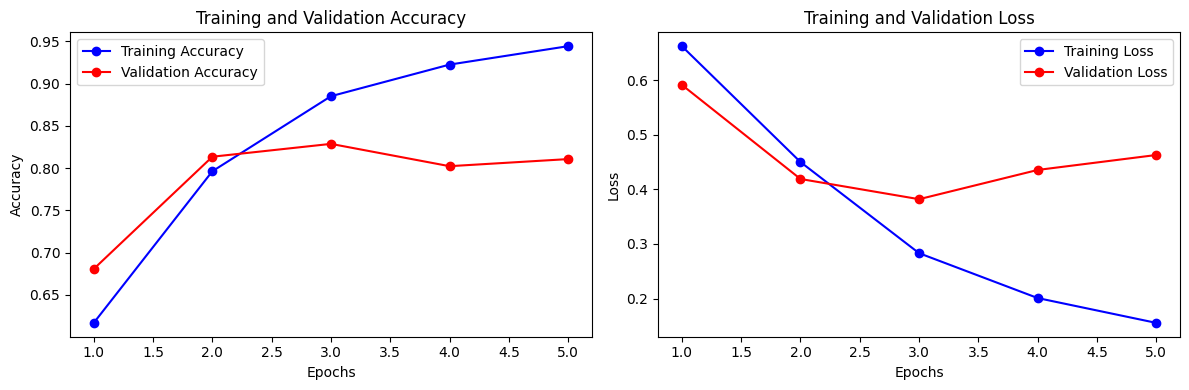

In [5]:
import matplotlib.pyplot as plt

def plot_history(history):
  # Extract values from history
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(acc)+1)

  # Plot the accuracy
  plt.figure(figsize = (12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs, acc, 'bo-', label= 'Training Accuracy')
  plt.plot(epochs, val_acc, 'ro-', label ='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  # Plot Loss
  plt.subplot(1,2,2)
  plt.plot(epochs, loss, 'bo-', label = 'Training Loss')
  plt.plot(epochs, val_loss, 'ro-', label = 'Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()

plot_history(history_mlp)

**The "Sweet Spot":** The model reached its peak performance on the validation set at Epoch 3. Beyond this point, any further training is hurting your model's ability to perform on unseen data (test data).

**Divergence:** Starting at Epoch 4, you can clearly see the "divergence" where Training Accuracy keeps climbing (92% → 94%) but Validation Accuracy drops or fluctuates while Validation Loss rises (0.38 → 0.46). This confirms the model is memorizing your training examples.

**Model 2: Long Short-Term Memory (LSTM)**

In [6]:
from tensorflow.keras.layers import LSTM

# Define the LSTM model architecture
model_lstm = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=200),
    # LSTM layer captures sequence dependencies
    layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the LSTM model
history_lstm = model_lstm.fit(
    train_padded, y_train,
    epochs=5,
    validation_data=(test_padded, y_test),
    batch_size=64 # Slightly larger batch size for LSTM efficiency
)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 71s 782ms/step - accuracy: 0.5060 - loss: 0.6935 - val_accuracy: 0.5124 - val_loss: 0.6927
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 788ms/step - accuracy: 0.5680 - loss: 0.6744 - val_accuracy: 0.5292 - val_loss: 0.6883
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 812ms/step - accuracy: 0.6322 - loss: 0.5794 - val_accuracy: 0.5484 - val_loss: 0.7272
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 793ms/step - accuracy: 0.6836 - loss: 0.4857 - val_accuracy: 0.5342 - val_loss: 0.7644
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 782ms/step - accuracy: 0.7010 - loss: 0.4458 - val_accuracy: 0.5490 - val_loss: 0.9413


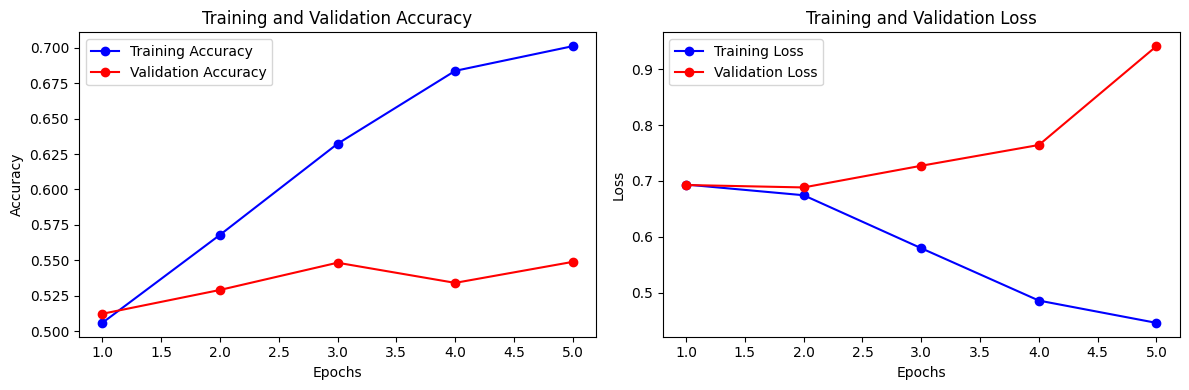

In [7]:
plot_history(history_lstm)

**Interpretation:** The LSTM is clearly "memorizing" the training set patterns very aggressively. The sharp increase in val_loss (0.72 to 0.94) indicates the model is becoming overly confident in its specific training examples and losing its ability to generalize.

**Model 3: Gated Recurrent Unit (GRU)**

In [8]:
from tensorflow.keras.layers import GRU

# Define the GRU model architecture
model_gru = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=200),
    # GRU layer: computationally more efficient than LSTM
    layers.GRU(128, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary output
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the GRU model
history_gru = model_gru.fit(
    train_padded, y_train,
    epochs=5,
    validation_data=(test_padded, y_test),
    batch_size=64
)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 59s 706ms/step - accuracy: 0.5020 - loss: 0.6939 - val_accuracy: 0.5124 - val_loss: 0.6928
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 81s 692ms/step - accuracy: 0.5616 - loss: 0.6743 - val_accuracy: 0.5176 - val_loss: 0.7052
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 56s 706ms/step - accuracy: 0.6264 - loss: 0.5820 - val_accuracy: 0.5248 - val_loss: 0.7654
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 81s 696ms/step - accuracy: 0.6668 - loss: 0.5132 - val_accuracy: 0.5378 - val_loss: 0.8986
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 56s 706ms/step - accuracy: 0.6944 - loss: 0.4498 - val_accuracy: 0.5198 - val_loss: 1.0055


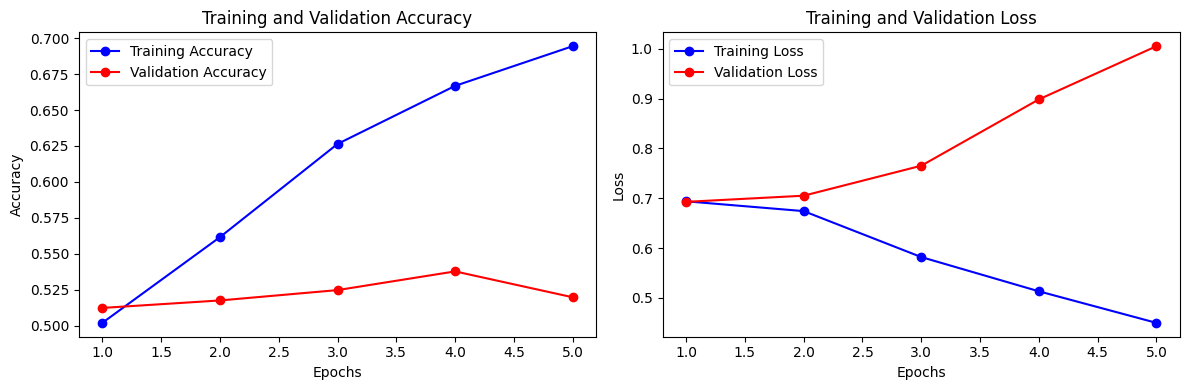

In [10]:
plot_history(history_gru)

**Interpretation:** The GRU shows slightly more instability in the loss than the LSTM. While it is theoretically more efficient, in this specific configuration, it is struggling to find a stable representation of the data before the weights become too skewed toward the training set.

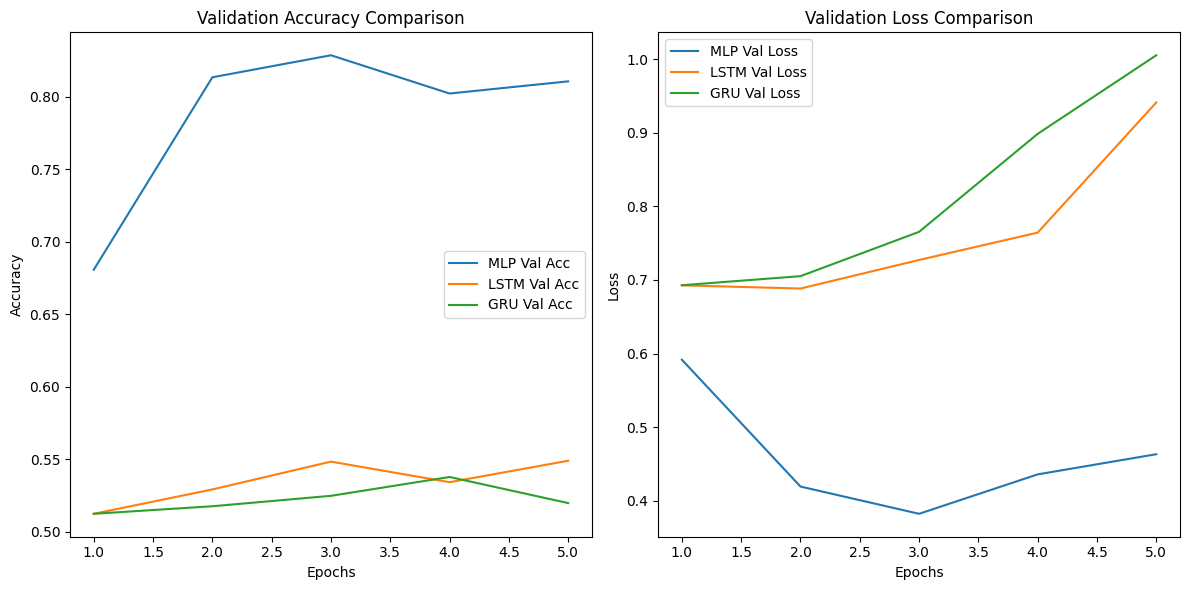

In [9]:
def plot_all_histories(histories, names):
  plt.figure(figsize = (12,6))

  # Plot Validation Accuracy
  plt.subplot(1 ,2, 1)
  epochs = range(1, len(histories[0].history['val_accuracy']) + 1)
  for hist, name in zip(histories, names):
    plt.plot(epochs, hist.history['val_accuracy'], label = f'{name} Val Acc')
  plt.title('Validation Accuracy Comparison')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  # Plot Validation Loss
  plt.subplot(1,2,2)
  for hist, name in zip(histories, names):
    plt.plot(epochs, hist.history['val_loss'], label = f'{name} Val Loss')
  plt.title('Validation Loss Comparison')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()

plot_all_histories([history_mlp, history_lstm, history_gru], ['MLP', 'LSTM', 'GRU'])

In [11]:
import pandas as pd

data = {
    'Model': ['MLP', 'LSTM', 'GRU'],
    'Validation Accuracy': [np.max(history_mlp.history['val_accuracy']),
                            np.max(history_lstm.history['val_accuracy']),
                            np.max(history_gru.history['val_accuracy'])],
    'Validation Loss': [np.min(history_mlp.history['val_loss']),
                        np.min(history_lstm.history['val_loss']),
                        np.min(history_gru.history['val_loss'])]
}
results = pd.DataFrame(data)
results

,Model,Validation Accuracy,Validation Loss
0,MLP,0.8288,0.382102
1,LSTM,0.5490,0.688345
2,GRU,0.5378,0.692848


<Axes: xlabel='Model'>

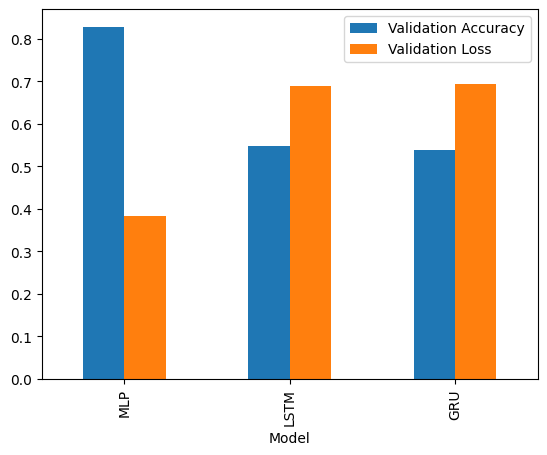

In [23]:
results.plot(kind='bar')

In [12]:
# Save the model
model_mlp.save('sentiment_mlp_model.keras')
print("Model saved successfully as 'sentiment_mlp_model.keras'")

Model saved successfully as 'sentiment_mlp_model.keras'


In [19]:
text = "The acting was great, but the story was honestly a bit of a mess."
text_s = clean_text(text)
text = tokenizer.texts_to_sequences([text_s])
text_p = pad_sequences(text, maxlen = 200, padding = 'post', truncating = 'post')
y_pred = model_mlp.predict(text_p)
print("Positive" if y_pred >=0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Positive


## **4. Model Recommendation**
I recommend the MLP (Multi-Layer Perceptron) as the final production model. While recurrent architectures are theoretically more advanced for text, the MLP achieved the highest validation accuracy (~83%) and proved to be significantly more stable. It avoided the severe overfitting and loss divergence observed in the LSTM and GRU models on this specific dataset.
## **5. Key Findings and Insights**
* **Lexical Markers vs. Sequence:** The data suggests that movie sentiment is driven more by key positive/negative words ("signal") than by complex word order, explaining why the MLP outperformed the RNN-based models.
* **Overfitting Threshold:** All models showed signs of overfitting beyond Epoch 3. This indicates that our current dataset size and architecture are prone to memorizing noise if training continues too long.
* **Computational Efficiency:** The MLP reached peak performance in $<15$ seconds, whereas recurrent models took $>250$ seconds, making the MLP the most scalable and cost-effective choice for production.
## **7. Next Steps**
* **Hyperparameter Optimization:**
Utilize KerasTuner to perform a formal search for optimal dropout rates and learning rates for the LSTM/GRU models to see if they can be stabilized.
* **Data Expansion:** Increasing the training volume may allow the recurrent architectures to learn long-range dependencies effectively without succumbing to the noise that currently causes overfitting.
* **Model Export:** The final MLP model has been saved as sentiment_mlp_model.keras for immediate deployment into an inference pipeline.